In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
#Imports the Image and ImageOps modules from PIL (Python Imaging Library), which
#are used for opening, manipulating, and saving many different image file formats
from PIL import Image, ImageOps
import os
import numpy as np
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

import keras

In [ ]:
%cd  /content/drive/MyDrive/finger&tinyml

/content/drive/MyDrive/finger&tinyml


In [ ]:
#!unzip "/content/drive/MyDrive/finger&tinyml/Real.zip" -d "/content/drive/MyDrive/finger&tinyml"

In [ ]:
# Load the CSV file
data = pd.read_csv('dataset.csv')

# Encode the labels (Type column)
label_encoder = LabelEncoder()
data['Type'] = label_encoder.fit_transform(data['Type'])


In [ ]:
def load_and_preprocess_image(image_path, folder_name='Real', target_size=(128, 128)):
    #print(image_path)
    full_path = os.path.join(folder_name, image_path)
    #print(full_path)
    #img = load_img(full_path, target_size=target_size)
    img = load_img(full_path, target_size=target_size, color_mode="grayscale")
    img_array = img_to_array(img) / 255.0  # Normalize pixel values to [0, 1]
    return img_array

# Assuming 'Image1' and 'Image2' are columns in your DataFrame 'data'
#data['Image1'] = data['Image1'].apply(lambda x: load_and_preprocess_image(x))
#data['Image2'] = data['Image2'].apply(lambda x: load_and_preprocess_image(x))


#optimisation of the function
# Create a dictionary to store preprocessed images
preprocessed_images = {}

# Function to preprocess an image if not already done
def get_or_process_image(image_path):
    if image_path not in preprocessed_images:
        preprocessed_images[image_path] = load_and_preprocess_image(image_path)
    return preprocessed_images[image_path]

# Update the DataFrame using the optimized approach
data['Image1'] = data['Image1'].apply(get_or_process_image)
data['Image2'] = data['Image2'].apply(get_or_process_image)

In [ ]:
#data

In [ ]:
print(len(data))

11700


In [ ]:
# Assuming 'data' is your DataFrame
shuffled_data = data.sample(frac=1, random_state=42)  # Shuffle the data

# Split the shuffled data into training and testing sets
train_data, val_data = train_test_split(shuffled_data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(val_data, test_size=0.2, random_state=42)

In [ ]:
def euclidean_distance(vects):
    x, y = vects
    sum_square = tf.math.reduce_sum(tf.math.square(x - y), axis=1, keepdims=True)
    return tf.math.sqrt(sum_square)

    #x, y = vects
    #sum_square = ops.sum(ops.square(x - y), axis=1, keepdims=True)
    #sum_square = tf.math.sum(tf.math.square(x - y), axis=1, keepdims=True)
    #return ops.sqrt(ops.maximum(sum_square, keras.backend.epsilon()))
    #return tf.math.sqrt(tf.math.maximum(sum_square, keras.backend.epsilon()))


input = keras.layers.Input((128,128,1))
x = keras.layers.BatchNormalization()(input)
x = keras.layers.Conv2D(4, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(16, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Flatten()(x)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(10, activation="tanh")(x)
embedding_network = keras.Model(input, x)


input_1 = keras.layers.Input((128, 128, 1))
input_2 = keras.layers.Input((128, 128, 1))

# As mentioned above, Siamese Network share weights between
# tower networks (sister networks). To allow this, we will use
# same embedding network for both tower networks.
tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))(
    [tower_1, tower_2]
)
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

In [ ]:
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """
        y_true = tf.cast(y_true, tf.float32)  # Cast y_true to float32
        y_pred = tf.cast(y_pred, tf.float32)  # Cast y_pred to float32

        square_pred = tf.math.square(y_pred)
        margin_square = tf.math.square(tf.math.maximum(margin - (y_pred), 0))
        return tf.reduce_mean((1 - y_true) * square_pred + (y_true) * margin_square)
        #return tf.math.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [ ]:
epochs = 70
batch_size = 16
margin = 1  # Margin for contrastive loss.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
siamese.compile(loss=loss(margin=margin), optimizer=optimizer, metrics=["accuracy"])

#siamese.compile(loss=loss(margin=margin), optimizer="RMSprop", metrics=["accuracy"])
siamese.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 10)             │        190,118 │ input_layer_1[0][0],   │
│                           │                        │                │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 1)              │              0 │ functional[0][0],      │
│                           │                        │                │ functional[1][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 1)              │              4 │ lambda[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │              2 │ batch_normalization_2… │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 190,124 (742.67 KB)

 Trainable params: 163,208 (637.53 KB)

 Non-trainable params: 26,916 (105.14 KB)

In [ ]:
X_train = [np.stack(train_data['Image1']), np.stack(train_data['Image2'])]
y_train = train_data['Type']

X_val = [np.stack(val_data['Image1']), np.stack(val_data['Image2'])]
y_val = val_data['Type']

y_train = y_train.astype('float32')
y_val = y_val.astype('float32')

history = siamese.fit(
   X_train, y_train,
   validation_data=(X_val,y_val),
    batch_size=batch_size,
    epochs=epochs,
)

Epoch 1/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.5253 - loss: 0.2628 - val_accuracy: 0.5591 - val_loss: 0.2499
Epoch 2/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5754 - loss: 0.2461 - val_accuracy: 0.5819 - val_loss: 0.2422
Epoch 3/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6011 - loss: 0.2360 - val_accuracy: 0.5933 - val_loss: 0.2378
Epoch 4/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6314 - loss: 0.2266 - val_accuracy: 0.6026 - val_loss: 0.2346
Epoch 5/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6470 - loss: 0.2210 - val_accuracy: 0.6111 - val_loss: 0.2312
Epoch 6/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6721 - loss: 0.2124 - val_accuracy: 0.6172 - val_loss: 0.2289
Epoch 7/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6940 - loss: 0.2068 - val_accuracy: 0.6211 - val_loss: 0.2264
Epoch 8/70
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6976 - loss: 0.2038 - val_accuracy: 

In [ ]:
total_params = siamese.count_params()
print(f"Nombre total de paramètres : {total_params}")


Nombre total de paramètres : 190124


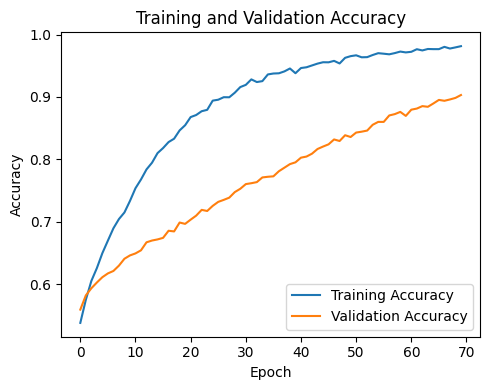

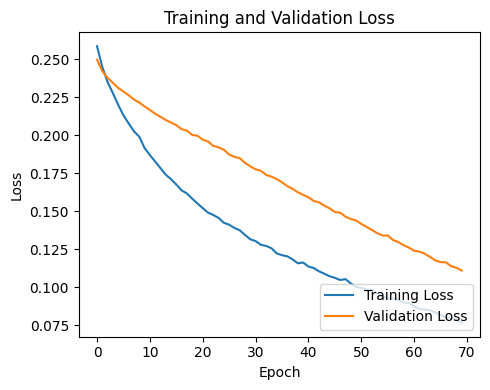

In [ ]:
import matplotlib.pyplot as plt

def plt_metric(history, metric, title, has_valid=True):
    """Plots the given 'metric' from 'history'.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as a key in 'history'.
        title: A string to be used as the title of the plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.figure(figsize=(5, 4))

    plt.plot(history[metric], label='Training ' + metric.capitalize())
    if has_valid:
        plt.plot(history["val_" + metric], label='Validation ' + metric.capitalize())
        plt.legend(loc='lower right')
    plt.ylabel(metric.capitalize())
    plt.xlabel('Epoch')
    plt.title('Training and Validation ' + metric.capitalize())

    plt.tight_layout()
    plt.show()

# Assuming 'history' is a valid history object from Model.fit
# Plot the accuracy
plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

# Plot the contrastive loss
plt_metric(history=history.history, metric="loss", title="Contrastive Loss")


In [ ]:
#print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
#os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
#!pip install --upgrade tensorflow

In [ ]:
#crach icici pb RAM , mais avant il donne une erreur voir cidessous, donc les resultats qui suivent sont de la version V1
results1 = siamese.evaluate(X_train, y_train)
print("train loss, train acc:", results1)

256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9990 - loss: 0.0501
train loss, train acc: [0.049747418612241745, 0.9991452693939209]


In [ ]:
X_test = [np.stack(test_data['Image1']), np.stack(test_data['Image2'])]
y_test = test_data['Type']

In [ ]:
results2 = siamese.evaluate(X_test, y_test)
#print("train loss, train acc:", results2)
print("test loss, test acc:", results2)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8959 - loss: 0.1158
test loss, test acc: [0.10989103466272354, 0.9074074029922485]


In [ ]:
import time
import numpy as np

# Run inference for all test samples and measure time
y_pred = []
inference_times = []

for i in range(len(X_test[0])):
    x1 = X_test[0][i:i+1]
    x2 = X_test[1][i:i+1]

    start_time = time.time()
    pred = siamese.predict([x1, x2], verbose=0)
    end_time = time.time()

    y_pred.append(pred[0][0])
    inference_times.append(end_time - start_time)

# Convert predictions to labels
y_pred = np.array(y_pred)
y_pred_labels = (y_pred > 0.5).astype(np.float32)

# Accuracy
accuracy = np.mean(y_pred_labels == y_test)
average_inference_time = np.mean(inference_times)

print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"⏱️ Average inference time per image pair: {average_inference_time:.6f} seconds")


✅ Test Accuracy: 0.9706
⏱️ Average inference time per image pair: 0.076335 seconds


In [ ]:
def visualize(pairs, labels, to_show=1, num_col=2, predictions=None, test=False):
    num_row = to_show // num_col if to_show // num_col != 0 else 1
    to_show = num_row * num_col

    # Plot the images
    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))

    for i in range(to_show):
        # If the number of rows is 1, the axes array is one-dimensional
        if num_row == 1:
            ax = axes[i % num_col]
        else:
            ax = axes[i // num_col, i % num_col]

        #ax.imshow(tf.math.concatenate([pairs[i][0], pairs[i][1]], axis=1), cmap="gray")
        ax.imshow(tf.concat([pairs[i][0], pairs[i][1]], axis=1), cmap="gray")
        ax.set_axis_off()
        if test:

            ax.set_title("True: {} | Pred: {:.5f}".format(labels[i], predictions[i][0]))

        else:
            ax.set_title("Label: {}".format(labels[i]))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    plt.show()

In [ ]:
type_list = y_test.tolist()

In [ ]:
#type_list

In [ ]:
print(len(type_list))

702


In [ ]:
X_test1=X_test[:2]

In [ ]:
print(len(X_test1))

2


In [ ]:
type_list1=type_list[:2]

In [ ]:
print(len(type_list1))

2


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


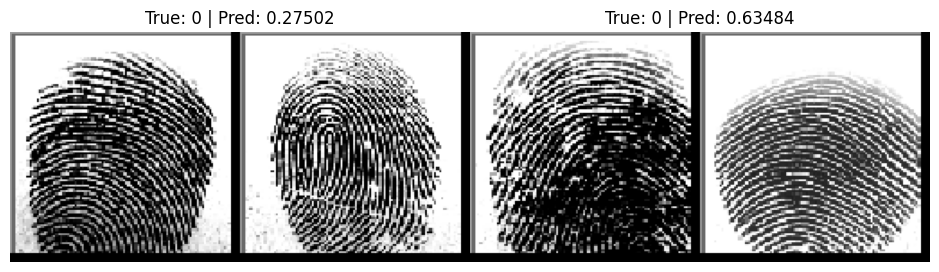

In [ ]:
predictions = siamese.predict(X_test)
visualize(X_test1, type_list1, to_show=2, predictions=predictions[:2], test=True)

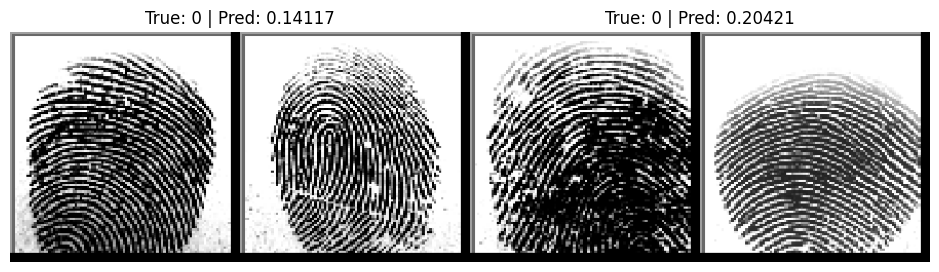

In [ ]:
save_path= "SNN_model128.h5"
siamese.save(save_path)

In [ ]:
#load_model = tf.keras.models.load_model(save_path)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


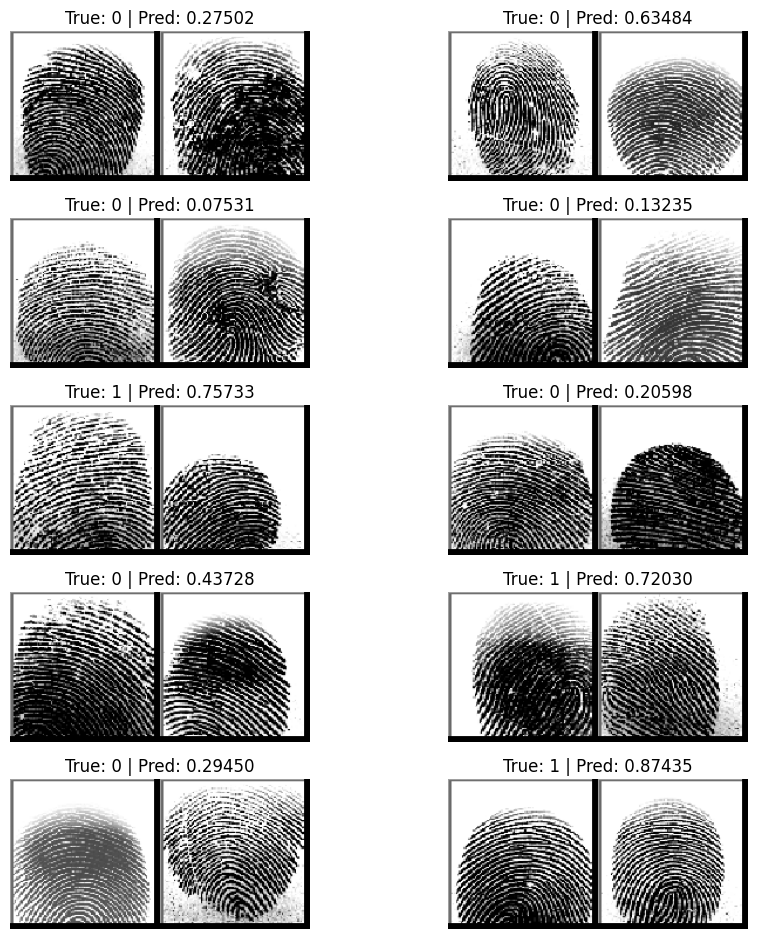

In [ ]:
def visualize2(pairs, labels, to_show=10, num_col=2, predictions=None, test=False):
    num_row = to_show // num_col if to_show // num_col != 0 else 1
    to_show = num_row * num_col

    # Plot the images
    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))

    for i in range(to_show):
        # If the number of rows is 1, the axes array is one-dimensional
        if num_row == 1:
            ax = axes[i % num_col]
        else:
            ax = axes[i // num_col, i % num_col]

        ax.imshow(tf.concat([pairs[0][i], pairs[1][i]], axis=1), cmap="gray")
        ax.set_axis_off()
        if test:

            ax.set_title("True: {} | Pred: {:.5f}".format(labels[i], predictions[i][0]))
            #print("i=",i)
            #print(labels[i])
            #print(predictions[i])
        else:
            ax.set_title("Label: {}".format(labels[i]))

    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    plt.show()

# Ensure that X_test and y_test have at least 10 pairs
type_list = y_test.tolist()
X_test2 = X_test[:10]
type_list2 = type_list[:10]
predictions = siamese.predict(X_test)
p=predictions[:10]
#p=p.tolist()
#print(p)
visualize2(X_test2, type_list2, to_show=10, predictions=predictions[:10], test=True)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Example true labels and predicted labels

predictions1=[1 if value >= 0.5 else 0 for value in predictions]
# Calculate precision, recall, and F1 score
precision = precision_score(y_test,predictions1)
recall = recall_score(y_test,predictions1)
f1 = f1_score(y_test,predictions1)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.875
Recall: 0.9442815249266863
F1 Score: 0.9083215796897038


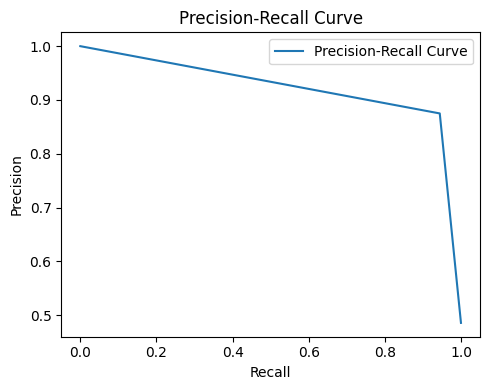

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Example true labels and predicted probabilities

# Calculate precision and recall values
precision, recall, thresholds = precision_recall_curve(y_test, predictions1)

# Plot the precision-recall curve with minimized size
plt.figure(figsize=(5, 4))  # Adjust the figure size as needed

plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

# Minimize white space around the plot
plt.tight_layout()

plt.show()



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions1)
cm

array([[315,  46],
       [ 19, 322]])

In [ ]:
#!pip install seaborn

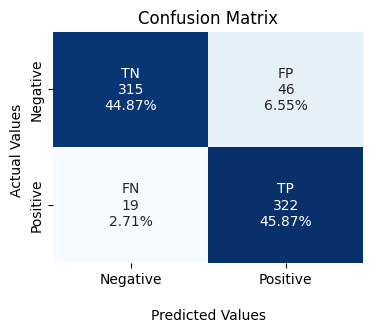

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and predictions1 defined

# Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, predictions1)

# Extracting TN, FP, FN, TP from the confusion matrix
TN, FP, FN, TP = cf_matrix.ravel()

# Group names, counts, and percentages
group_names = ['TN', 'FP', 'FN', 'TP']
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

# Plot the confusion matrix with annotations
f, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Set labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')


## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Negative','Positive'])
ax.yaxis.set_ticklabels(['Negative','Positive'])

# Display the visualization of the Confusion Matrix
plt.show()


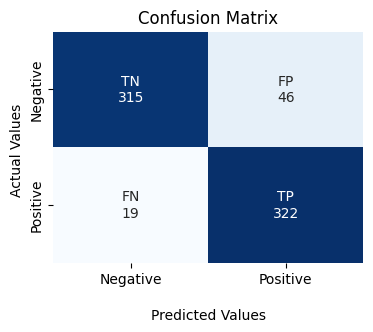

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and predictions1 defined

# Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, predictions1)

# Extracting TN, FP, FN, TP from the confusion matrix
TN, FP, FN, TP = cf_matrix.ravel()

# Group names and counts
group_names = ['TN', 'FP', 'FN', 'TP']
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

# Plot the confusion matrix with annotations
f, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Set labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')

# Set tick labels
ax.xaxis.set_ticklabels(['Negative','Positive'])
ax.yaxis.set_ticklabels(['Negative','Positive'])

# Display the visualization of the Confusion Matrix
plt.show()


# **Quantization**

In [ ]:
!pip install tensorflow_model_optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 102.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
import tensorflow as tf
import numpy as np
import tensorflow_model_optimization as tfmot

# 1️⃣ Define the custom function before loading the model
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """
        y_true = tf.cast(y_true, tf.float32)  # Cast y_true to float32
        y_pred = tf.cast(y_pred, tf.float32)  # Cast y_pred to float32

        square_pred = tf.math.square(y_pred)
        margin_square = tf.math.square(tf.math.maximum(margin - (y_pred), 0))
        return tf.reduce_mean((1 - y_true) * square_pred + (y_true) * margin_square)
        #return tf.math.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

# Register the function
tf.keras.utils.get_custom_objects()["euclidean_distance"] = euclidean_distance

# 2️⃣ Load the trained Keras model
from tensorflow.keras.models import load_model
model = load_model('SNN_model128.h5', custom_objects={'contrastive_loss': loss})

# 3️⃣ Function to save a TFLite model
def save_tflite_model(converter, save_path):
    tflite_model = converter.convert()
    with open(save_path, "wb") as f:
        f.write(tflite_model)
    print(f"✅ Model saved at: {save_path}")

In [ ]:
# 4️⃣ **Dynamic Range Quantization**
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Default optimizations
save_tflite_model(converter, "SNN_dynamic_range.tflite")

Saved artifact at '/tmp/tmptr_uisec'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_1'), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_2')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134205399952336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399951376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399952144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399951184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399953872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399954448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399953488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399955216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399955408: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
def representative_data_gen():
    for _ in range(100):
        # Generate two random fingerprint images as a pair
        dummy_input_1 = np.random.rand(1, 128, 128, 1).astype(np.float32)
        dummy_input_2 = np.random.rand(1, 128, 128, 1).astype(np.float32)
        yield [dummy_input_1, dummy_input_2]  # Return a tuple of inputs

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen  # Pass correct dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # Force input to be int8
converter.inference_output_type = tf.int8  # Force output to be int8
save_tflite_model(converter, "SNN_full_integer.tflite")


Saved artifact at '/tmp/tmpzkum5fta'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_1'), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_2')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134205399952336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399951376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399952144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399951184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399953872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399954448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399953488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399955216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205399955408: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Model saved at: SNN_full_integer.tflite


In [ ]:
import tensorflow as tf
import numpy as np
import tensorflow_model_optimization as tfmot


import tensorflow as tf
import numpy as np
import tensorflow_model_optimization as tfmot
def euclidean_distance(vects):
    x, y = vects
    sum_square = tf.math.reduce_sum(tf.math.square(x - y), axis=1, keepdims=True)
    return tf.math.sqrt(sum_square)
# 1️⃣ Define the custom function before loading the model
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """
        y_true = tf.cast(y_true, tf.float32)  # Cast y_true to float32
        y_pred = tf.cast(y_pred, tf.float32)  # Cast y_pred to float32

        square_pred = tf.math.square(y_pred)
        margin_square = tf.math.square(tf.math.maximum(margin - (y_pred), 0))
        return tf.reduce_mean((1 - y_true) * square_pred + (y_true) * margin_square)
        #return tf.math.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

# Register the function
tf.keras.utils.get_custom_objects()["euclidean_distance"] = euclidean_distance
from tensorflow.keras.models import load_model
model = load_model('SNN_model128.h5', custom_objects={'contrastive_loss': loss})
# 3️⃣ Function to save a TFLite model
def save_tflite_model(converter, save_path):
    tflite_model = converter.convert()
    with open(save_path, "wb") as f:
        f.write(tflite_model)
    print(f"✅ Model saved at: {save_path}")

# Function to generate representative data
def representative_data_gen():
    for _ in range(100):
        dummy_input_1 = np.random.rand(1, 128, 128, 1).astype(np.float32)
        dummy_input_2 = np.random.rand(1, 128, 128, 1).astype(np.float32)
        yield [dummy_input_1, dummy_input_2]


In [ ]:
# 6️⃣ Float16 Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
save_tflite_model(converter, "SNN_float16.tflite")

Saved artifact at '/tmp/tmp3k9qgkib'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_1'), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_2')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134210574447248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398744912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210574445136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210574445904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398743568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398742992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398744336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398742224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398742032: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# 7️⃣ Hybrid Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
save_tflite_model(converter, "SNN_hybrid.tflite")

Saved artifact at '/tmp/tmp5ibyrjsa'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_1'), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_2')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134210574447248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398744912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210574445136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210574445904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398743568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398742992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398744336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398742224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134205398742032: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
#error in:
# quantization aware training
#8️⃣ Weight Pruning
# Cluster Pruning

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import time
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the test dataset
test_data = pd.read_csv("dataset.csv")  # Ensure this file contains the correct test set

# Function to load and preprocess images
def load_and_preprocess_image(image_path, folder_name='Real', target_size=(128, 128)):
    full_path = os.path.join(folder_name, image_path)
    img = load_img(full_path, target_size=target_size, color_mode="grayscale")
    img_array = img_to_array(img) / 255.0  # Normalize pixel values to [0, 1]
    return img_array.astype(np.float32)

# Apply preprocessing to test images
X_test_1 = np.stack(test_data["Image1"].apply(load_and_preprocess_image))
X_test_2 = np.stack(test_data["Image2"].apply(load_and_preprocess_image))
y_test = test_data["Type"].values.astype(np.float32)

# Convert X_test into the correct format (list of two arrays)
X_test = [X_test_1, X_test_2]

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="SNN_dynamic_range.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ensure input tensors match expected dtype
X_test_1 = X_test_1.astype(input_details[0]["dtype"])
X_test_2 = X_test_2.astype(input_details[1]["dtype"])

# Run inference on test data
y_pred = []
inference_times = []

for i in range(len(X_test_1)):
    # Set input tensors
    interpreter.set_tensor(input_details[0]['index'], X_test_1[i:i+1])
    interpreter.set_tensor(input_details[1]['index'], X_test_2[i:i+1])

    # Start timing
    start_time = time.time()

    # Run inference
    interpreter.invoke()

    # End timing
    end_time = time.time()
    inference_times.append(end_time - start_time)

    # Get output tensor
    prediction = interpreter.get_tensor(output_details[0]['index'])[0][0]
    y_pred.append(prediction)

# Convert predictions to binary labels (0 or 1)
y_pred = np.array(y_pred)
y_pred_labels = (y_pred > 0.5).astype(np.float32)

# Compute accuracy
accuracy = np.mean(y_pred_labels == y_test)
print(f"✅ TFLite Model Accuracy on Test Set: {accuracy:.4f}")
print(f"⏱️ Temps moyen d'inférence par image : {np.mean(inference_times):.6f} secondes")


✅ TFLite Model Accuracy on Test Set: 0.9709
⏱️ Temps moyen d'inférence par image : 0.001183 secondes


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import time
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the test dataset
test_data = pd.read_csv("dataset.csv")  # Ensure this file contains the correct test set

# Function to load and preprocess images
def load_and_preprocess_image(image_path, folder_name='Real', target_size=(128, 128)):
    full_path = os.path.join(folder_name, image_path)
    img = load_img(full_path, target_size=target_size, color_mode="grayscale")
    img_array = img_to_array(img) / 255.0  # Normalize pixel values to [0, 1]
    return img_array.astype(np.float32)

# Apply preprocessing to test images
X_test_1 = np.stack(test_data["Image1"].apply(load_and_preprocess_image))
X_test_2 = np.stack(test_data["Image2"].apply(load_and_preprocess_image))
y_test = test_data["Type"].values.astype(np.float32)

# Convert X_test into the correct format (list of two arrays)
X_test = [X_test_1, X_test_2]

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="SNN_full_integer.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ensure input tensors match expected dtype (int8 for full-integer quantization)
X_test_1 = (X_test_1 * 255).astype(np.int8)  # Scale and convert to int8
X_test_2 = (X_test_2 * 255).astype(np.int8)  # Scale and convert to int8

# Run inference on test data
y_pred = []
inference_times = []

for i in range(len(X_test_1)):
    # Set input tensors
    interpreter.set_tensor(input_details[0]['index'], X_test_1[i:i+1])
    interpreter.set_tensor(input_details[1]['index'], X_test_2[i:i+1])

    # Start timing
    start_time = time.time()

    # Run inference
    interpreter.invoke()

    # End timing
    end_time = time.time()
    inference_times.append(end_time - start_time)

    # Get output tensor
    prediction = interpreter.get_tensor(output_details[0]['index'])[0][0]
    y_pred.append(prediction)

# Convert predictions to binary labels (0 or 1)
y_pred = np.array(y_pred)
y_pred_labels = (y_pred > 0.5).astype(np.float32)

# Compute accuracy
accuracy = np.mean(y_pred_labels == y_test)
print(f"✅ TFLite Model Accuracy on Test Set (Full Integer): {accuracy:.4f}")
print(f"⏱️ Temps moyen d'inférence par image : {np.mean(inference_times):.6f} secondes")


✅ TFLite Model Accuracy on Test Set (Full Integer): 0.5126
⏱️ Temps moyen d'inférence par image : 0.002169 secondes


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import time
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the test dataset
test_data = pd.read_csv("dataset.csv")  # Ensure this file contains the correct test set

# Function to load and preprocess images
def load_and_preprocess_image(image_path, folder_name='Real', target_size=(128, 128)):
    full_path = os.path.join(folder_name, image_path)
    img = load_img(full_path, target_size=target_size, color_mode="grayscale")
    img_array = img_to_array(img) / 255.0  # Normalize pixel values to [0, 1]
    return img_array.astype(np.float32)

# Apply preprocessing to test images
X_test_1 = np.stack(test_data["Image1"].apply(load_and_preprocess_image))
X_test_2 = np.stack(test_data["Image2"].apply(load_and_preprocess_image))
y_test = test_data["Type"].values.astype(np.float32)

# Convert X_test into the correct format (list of two arrays)
X_test = [X_test_1, X_test_2]

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="SNN_float16.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ensure input tensors match expected dtype (float32 for float16 models)
X_test_1 = X_test_1.astype(np.float32)
X_test_2 = X_test_2.astype(np.float32)

# Run inference on test data
y_pred = []
inference_times = []

for i in range(len(X_test_1)):
    # Set input tensors
    interpreter.set_tensor(input_details[0]['index'], X_test_1[i:i+1])
    interpreter.set_tensor(input_details[1]['index'], X_test_2[i:i+1])

    # Start timing
    start_time = time.time()

    # Run inference
    interpreter.invoke()

    # End timing
    end_time = time.time()
    inference_times.append(end_time - start_time)

    # Get output tensor
    prediction = interpreter.get_tensor(output_details[0]['index'])[0][0]
    y_pred.append(prediction)

# Convert predictions to binary labels (0 or 1)
y_pred = np.array(y_pred)
y_pred_labels = (y_pred > 0.5).astype(np.float32)

# Compute accuracy
accuracy = np.mean(y_pred_labels == y_test)
print(f"✅ TFLite Model Accuracy on Test Set (Float16): {accuracy:.4f}")
print(f"⏱️ Temps moyen d'inférence par image : {np.mean(inference_times):.6f} secondes")


✅ TFLite Model Accuracy on Test Set (Float16): 0.9708
⏱️ Temps moyen d'inférence par image : 0.001446 secondes


In [ ]:
import os

# Define input and output file paths
tflite_model_path = "SNN_dynamic_range.tflite"
cc_output_path = "snn_model.cc"

# Read the TFLite model file
with open(tflite_model_path, "rb") as f:
    tflite_model = f.read()

# Convert to a C array
hex_array = ", ".join(f"0x{byte:02x}" for byte in tflite_model)

# Create C++ file content
cc_content = f"""#include "snn_model.h"

alignas(8) const unsigned char snn_model[] = {{
    {hex_array}
}};
const unsigned int snn_model_len = {len(tflite_model)};
"""

# Save to a .cc file
with open(cc_output_path, "w") as f:
    f.write(cc_content)

print(f"✅ Successfully saved TensorFlow Lite model as C++ array in {cc_output_path}")


✅ Successfully saved TensorFlow Lite model as C++ array in snn_model.cc


In [ ]:
!cat {cc_output_path}

#include "snn_model.h"

alignas(8) const unsigned char snn_model[] = {
    0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00, 0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0xb0, 0x00, 0x00, 0x00, 0x08, 0x01, 0x00, 0x00, 0x0c, 0x19, 0x02, 0x00, 0x1c, 0x19, 0x02, 0x00, 0x8c, 0x31, 0x02, 0x00, 0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x4e, 0xe2, 0xfd, 0xff, 0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f, 0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x6c, 0xff, 0xff, 0xff, 0x22, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70, 0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x02, 0x00, 0x00, 0x00, 0x24, 0x00, 0x00, 0x00, 0x04, 0x00, 0

In [ ]:
#.cc probleme size 2.6
#test other size of image like 128 and 64 ro se if they are gived same result in traing, if yes keep this one